# Made by

## Name      : Anthony Djiady Djie
## Class     : Dibimbing.id
## Topic     : Food Delivery Time Prediction
## Project   : Take Home Project Data Science

#

# SECTION 1: Setup, Business Understanding, and Data Loading

## 1.1 Dataset Background

This dataset contains operational information for food delivery orders, such as:

- delivery distance
- weather condition
- traffic level
- time of day
- vehicle type
- food preparation time
- courier experience

The target variable is **`Delivery_Time_min`**, which represents the total delivery time in minutes.

This is a suitable dataset for a **supervised machine learning regression project** because the goal is to predict a continuous numeric value.

## 1.2 Business Problem

Food delivery platforms need to estimate delivery time as accurately as possible before an order arrives.

If the prediction is inaccurate, several business problems can occur:

- customers become dissatisfied because food arrives later than expected
- restaurants receive complaints and poor ratings
- operations teams struggle to allocate couriers efficiently
- delivery promises become unreliable during bad weather or heavy traffic

By building a machine learning model to predict delivery time, the company can improve:

- customer satisfaction
- delivery planning
- courier allocation
- operational efficiency

## 1.3 Project Objective

The objective of this project is to build a regression model that predicts **food delivery time** based on operational and environmental factors.

Main goals:

1. Understand the dataset structure and data quality  
2. Perform exploratory data analysis (EDA)  
3. Engineer useful features for prediction  
4. Build and compare multiple regression models  
5. Evaluate which model performs best  
6. Translate the findings into business insights

## 1.4 Import Libraries

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

sns.set_theme(style="whitegrid")
print("Libraries imported successfully!")

Libraries imported successfully!


## 1.5 Load Dataset

In [ ]:
# Update this path if your dataset is stored in a different folder
file_path = "Food_Delivery_Times Dataset.csv"

df = pd.read_csv(file_path)
print("Dataset loaded successfully!")
df.head()

Dataset loaded successfully!


,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [ ]:
df.columns

Index(['Order_ID', 'Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day',
       'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs',
       'Delivery_Time_min'],
      dtype='object')

#

# SECTION 2: Data Understanding

## 2.1 Basic Data Inspection

In [ ]:
print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns\n")

print("Data types:")
print(df.dtypes, end="\n\n")

print("Missing values:")
print(df.isna().sum(), end="\n\n")

print("Summary statistics:")
display(df.describe(include="all").T)

Dataset shape: 1000 rows × 9 columns

Data types:
Order_ID                    int64
Distance_km               float64
Weather                    object
Traffic_Level              object
Time_of_Day                object
Vehicle_Type               object
Preparation_Time_min        int64
Courier_Experience_yrs    float64
Delivery_Time_min           int64
dtype: object

Missing values:
Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64

Summary statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Order_ID,1000.0,NaN,NaN,NaN,500.5,288.819436,1.0,250.75,500.5,750.25,1000.0
Distance_km,1000.0,NaN,NaN,NaN,10.05997,5.696656,0.59,5.105,10.19,15.0175,19.99
Weather,970,5,Clear,470,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Traffic_Level,970,3,Medium,390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Time_of_Day,970,4,Morning,308,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Vehicle_Type,1000,3,Bike,503,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Preparation_Time_min,1000.0,NaN,NaN,NaN,16.982,7.204553,5.0,11.0,17.0,23.0,29.0
Courier_Experience_yrs,970.0,NaN,NaN,NaN,4.579381,2.914394,0.0,2.0,5.0,7.0,9.0
Delivery_Time_min,1000.0,NaN,NaN,NaN,56.732,22.070915,8.0,41.0,55.5,71.0,153.0


### Observation

- The dataset contains both **numerical** and **categorical** features.
- The target column is **`Delivery_Time_min`**.
- Several categorical columns contain missing values.
- `Courier_Experience_yrs` also has missing values.
- `Order_ID` is only an identifier and is not useful as a predictive feature.

## 2.2 Check Unique Values

In [ ]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

Order_ID: 1000 unique values
Distance_km: 785 unique values
Weather: 5 unique values
Traffic_Level: 3 unique values
Time_of_Day: 4 unique values
Vehicle_Type: 3 unique values
Preparation_Time_min: 25 unique values
Courier_Experience_yrs: 10 unique values
Delivery_Time_min: 108 unique values


## 2.3 Identify Column Types

In [ ]:
categorical_cols = df.select_dtypes(include="object").columns.tolist()
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)

Categorical columns: ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']
Numerical columns: ['Order_ID', 'Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs', 'Delivery_Time_min']


### Observation

- **Categorical features**: `Weather`, `Traffic_Level`, `Time_of_Day`, `Vehicle_Type`
- **Numerical features**: `Distance_km`, `Preparation_Time_min`, `Courier_Experience_yrs`, `Delivery_Time_min`
- `Order_ID` should be treated as an identifier, not as a feature for modeling.

#

# SECTION 3: Exploratory Data Analysis (EDA)

## 3.1 Check Missing Values

In [ ]:
missing_df = df.isna().sum().reset_index()
missing_df.columns = ["column", "missing_count"]
missing_df["missing_pct"] = (missing_df["missing_count"] / len(df) * 100).round(2)
missing_df.sort_values("missing_count", ascending=False)

,column,missing_count,missing_pct
2,Weather,30,3.0
4,Time_of_Day,30,3.0
3,Traffic_Level,30,3.0
7,Courier_Experience_yrs,30,3.0
0,Order_ID,0,0.0
1,Distance_km,0,0.0
5,Vehicle_Type,0,0.0
6,Preparation_Time_min,0,0.0
8,Delivery_Time_min,0,0.0


### Observation

The missing values are relatively small compared with the dataset size, so they can be handled safely through imputation instead of deleting rows.

## 3.2 Visualize Target Distribution

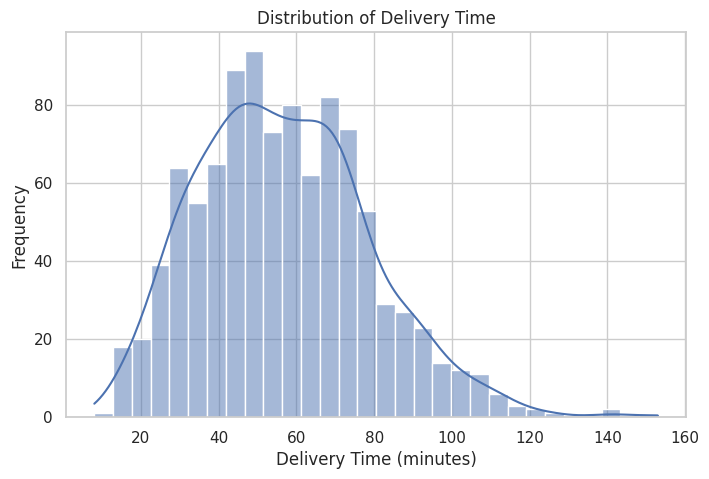

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["Delivery_Time_min"], bins=30, kde=True)
plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Frequency")
plt.show()

### Observation

This chart helps us understand whether the target variable is skewed, normally distributed, or contains unusual extreme values.

## 3.3 Numerical Feature Distribution

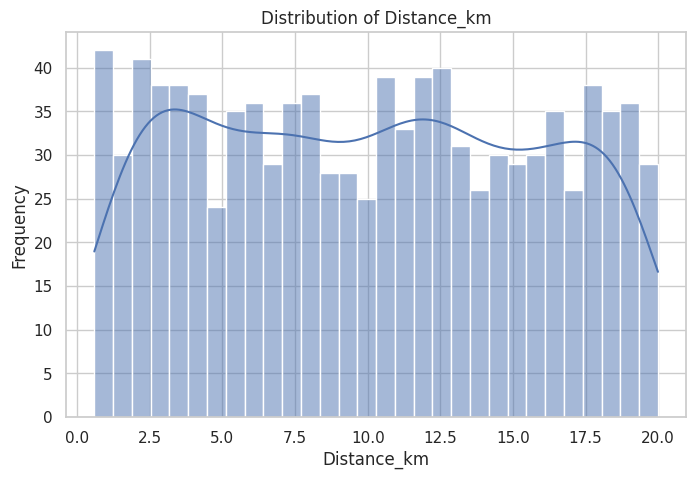

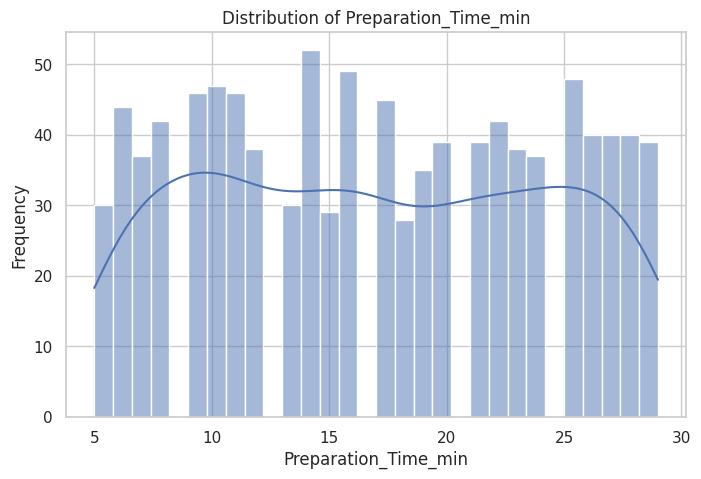

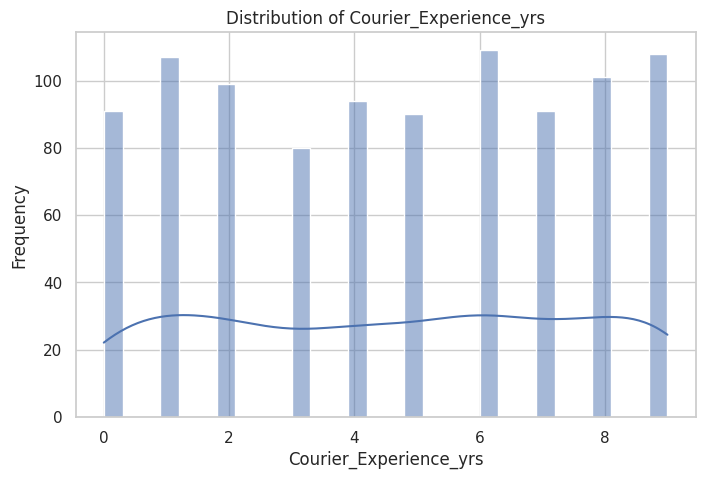

In [ ]:
num_plot_cols = ["Distance_km", "Preparation_Time_min", "Courier_Experience_yrs"]

for col in num_plot_cols:
    plt.figure(figsize=(8,5))
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

## 3.4 Categorical Feature Distribution

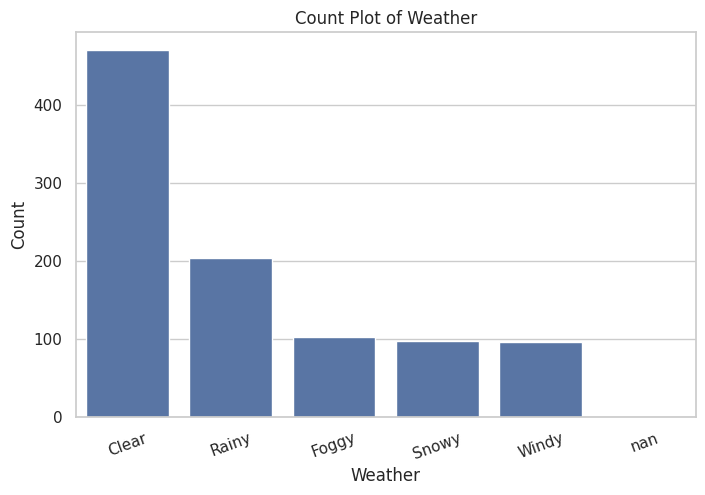

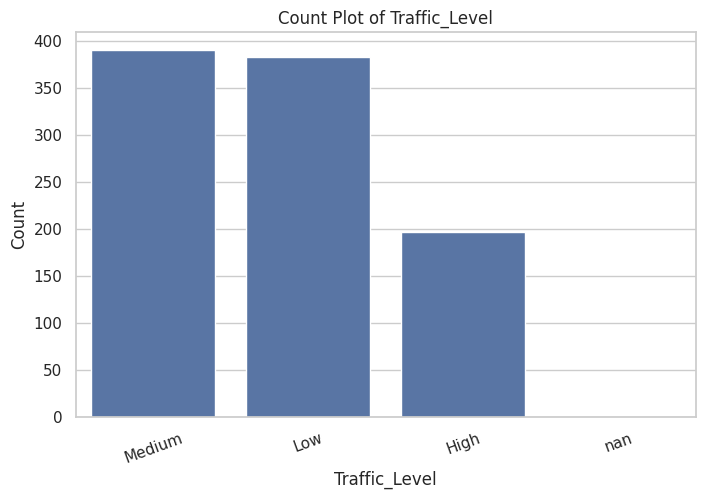

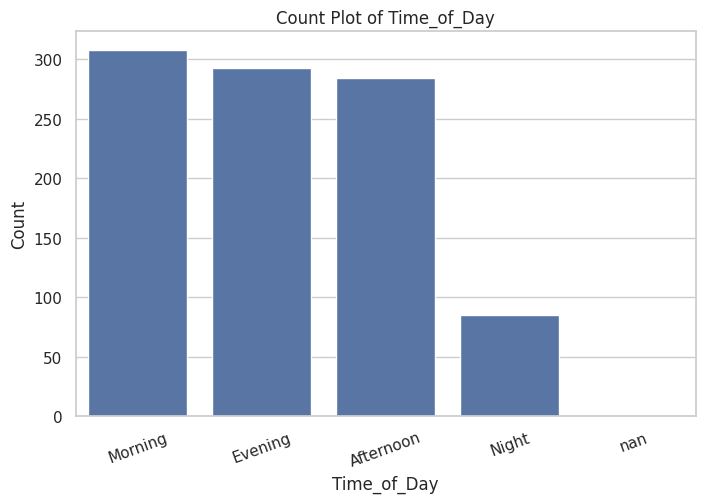

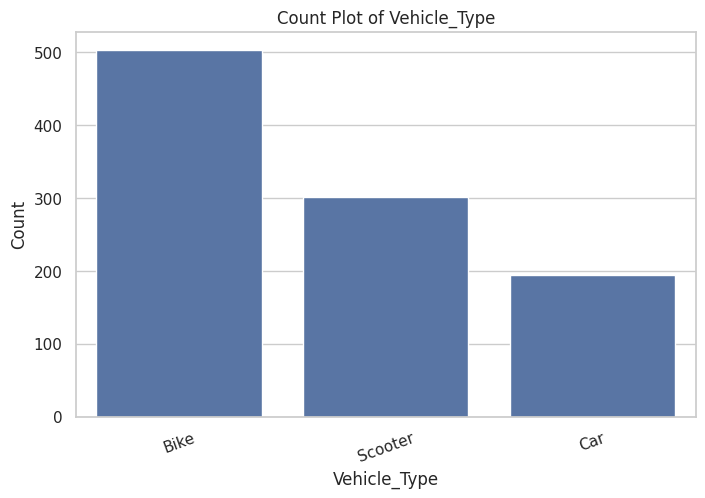

In [ ]:
cat_plot_cols = ["Weather", "Traffic_Level", "Time_of_Day", "Vehicle_Type"]

for col in cat_plot_cols:
    plt.figure(figsize=(8,5))
    sns.countplot(data=df, x=col, order=df[col].value_counts(dropna=False).index)
    plt.title(f"Count Plot of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=20)
    plt.show()

### Observation

These charts show the composition of each category and help identify whether some classes dominate the dataset.

## 3.5 Relationship Between Features and Target

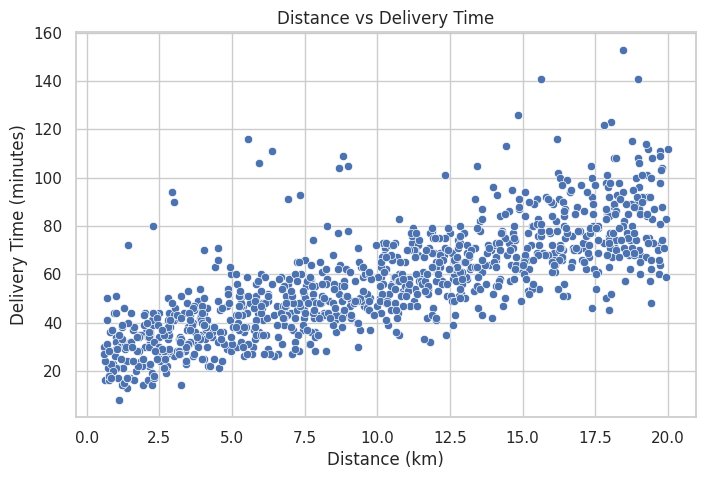

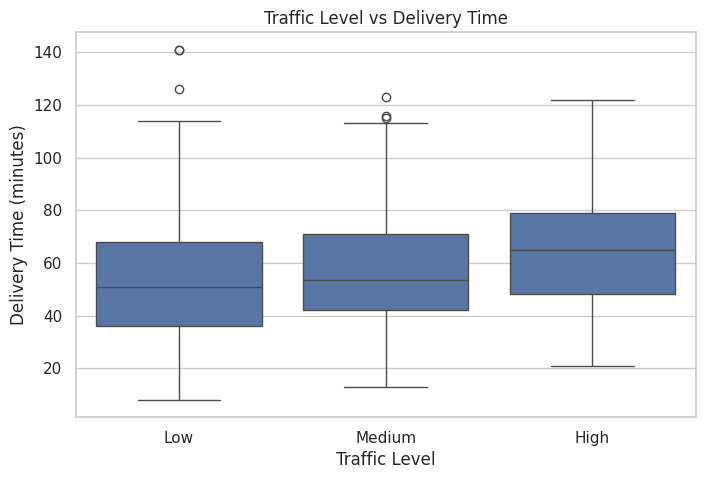

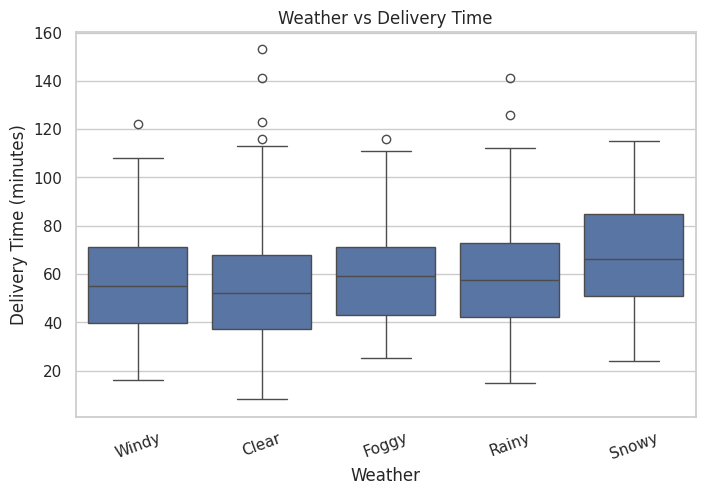

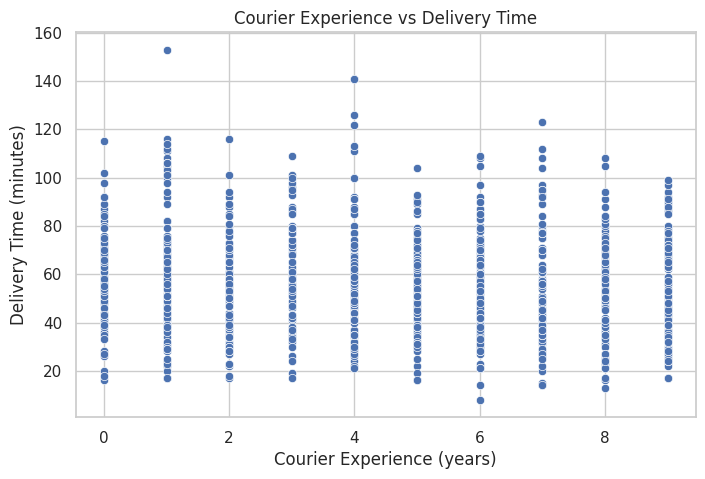

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Distance_km", y="Delivery_Time_min")
plt.title("Distance vs Delivery Time")
plt.xlabel("Distance (km)")
plt.ylabel("Delivery Time (minutes)")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Traffic_Level", y="Delivery_Time_min")
plt.title("Traffic Level vs Delivery Time")
plt.xlabel("Traffic Level")
plt.ylabel("Delivery Time (minutes)")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Weather", y="Delivery_Time_min")
plt.title("Weather vs Delivery Time")
plt.xlabel("Weather")
plt.ylabel("Delivery Time (minutes)")
plt.xticks(rotation=20)
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Courier_Experience_yrs", y="Delivery_Time_min")
plt.title("Courier Experience vs Delivery Time")
plt.xlabel("Courier Experience (years)")
plt.ylabel("Delivery Time (minutes)")
plt.show()

### Observation

Potential patterns we expect to see:

- longer distance tends to increase delivery time
- higher traffic tends to increase delivery time
- difficult weather conditions may slow deliveries
- more experienced couriers may complete deliveries faster

## 3.6 Correlation Matrix for Numerical Variables

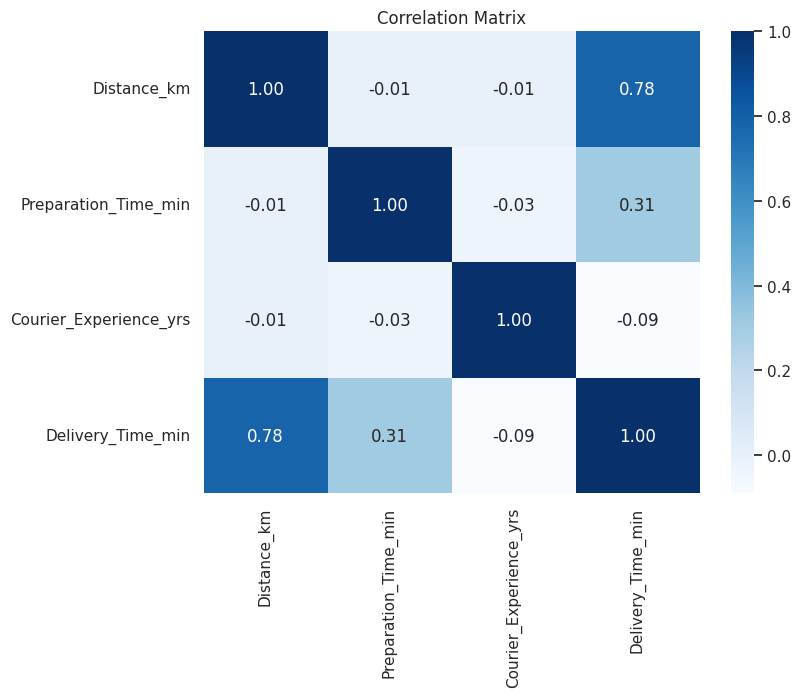

In [ ]:
plt.figure(figsize=(8,6))
corr = df[["Distance_km", "Preparation_Time_min", "Courier_Experience_yrs", "Delivery_Time_min"]].corr()
sns.heatmap(corr, annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

### Observation

This matrix helps us see which numerical variables have the strongest linear relationship with delivery time.

#

# SECTION 4: Data Cleaning and Feature Engineering

## 4.1 Drop Irrelevant Column

In [ ]:
df_model = df.drop(columns=["Order_ID"]).copy()
df_model.head()

,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,19.03,Clear,Low,Morning,Bike,16,5.0,68


### Observation

`Order_ID` is only an identifier and does not contain business information that helps predict delivery time.

## 4.2 Create Additional Features

In [ ]:
df_model["Is_Rush_Hour"] = df_model["Time_of_Day"].apply(
    lambda x: 1 if x in ["Morning", "Evening"] else 0 if pd.notna(x) else np.nan
)

df_model["Distance_x_Prep_Time"] = df_model["Distance_km"] * df_model["Preparation_Time_min"]

df_model.head()

,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Is_Rush_Hour,Distance_x_Prep_Time
0,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43,0.0,95.16
1,16.42,Clear,Medium,Evening,Bike,20,2.0,84,1.0,328.40
2,9.52,Foggy,Low,Night,Scooter,28,1.0,59,0.0,266.56
3,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37,0.0,37.20
4,19.03,Clear,Low,Morning,Bike,16,5.0,68,1.0,304.48


### Feature Engineering Rationale

- **`Is_Rush_Hour`** simplifies time-of-day into an operational flag
- **`Distance_x_Prep_Time`** captures interaction between travel distance and kitchen preparation time

These features may help the model capture more realistic delivery dynamics.

## 4.3 Check Outliers

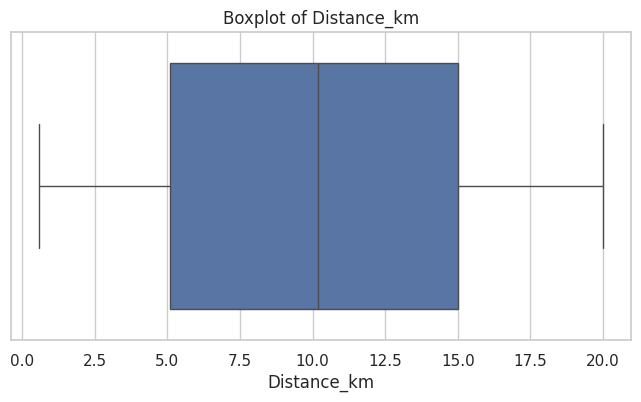

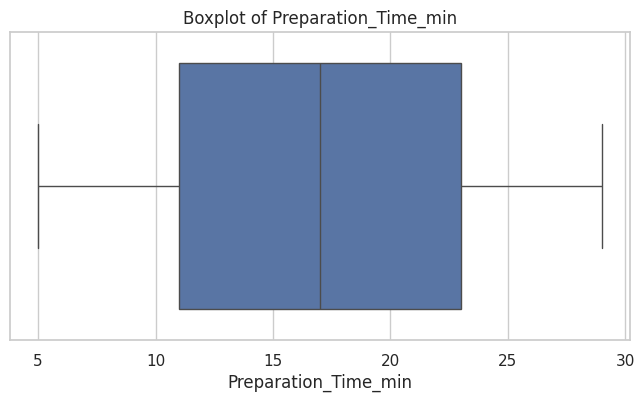

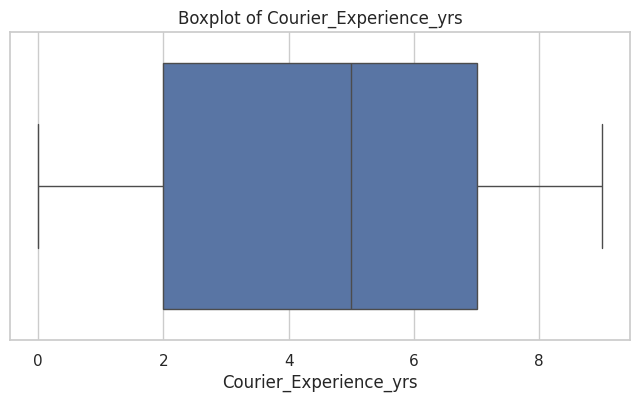

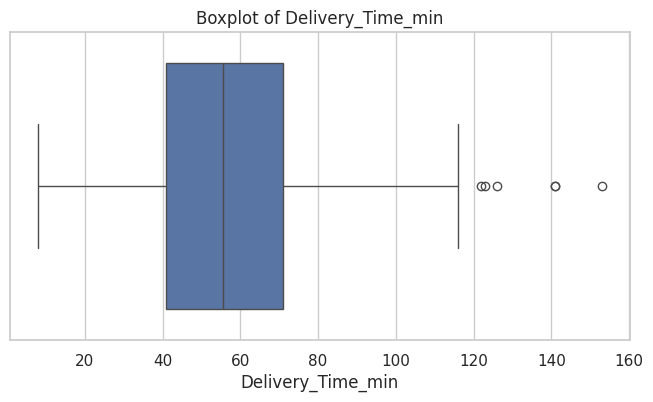

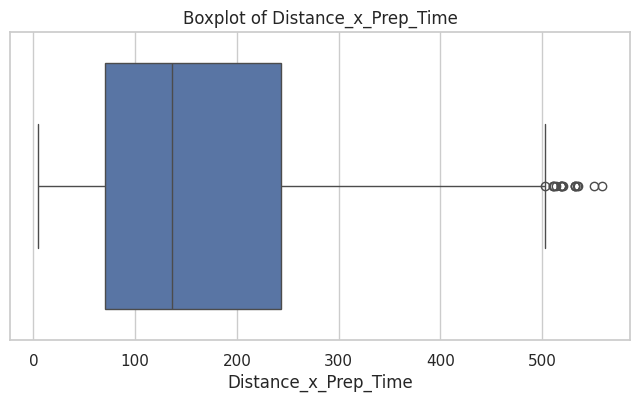

In [ ]:
outlier_cols = ["Distance_km", "Preparation_Time_min", "Courier_Experience_yrs", "Delivery_Time_min", "Distance_x_Prep_Time"]

for col in outlier_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df_model[col])
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

### Observation

Outliers are not always errors. In delivery operations, unusually long delivery times or long distances may represent valid real-world situations, so we will inspect them but not automatically remove them.

#

# SECTION 5: Data Preprocessing

## 5.1 Define Features and Target

In [ ]:
X = df_model.drop(columns=["Delivery_Time_min"])
y = df_model["Delivery_Time_min"]

categorical_features = X.select_dtypes(include="object").columns.tolist()
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical features:", categorical_features)
print("Numerical features:", numerical_features)

Categorical features: ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']
Numerical features: ['Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs', 'Is_Rush_Hour', 'Distance_x_Prep_Time']


## 5.2 Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (800, 9)
X_test shape: (200, 9)
y_train shape: (800,)
y_test shape: (200,)


## 5.3 Build Preprocessing Pipeline

In [ ]:
from sklearn.preprocessing import StandardScaler

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


#

# SECTION 6: Modeling

## 6.1 Define Models

In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

models

{'Linear Regression': LinearRegression(),
 'Random Forest': RandomForestRegressor(random_state=42),
 'Gradient Boosting': GradientBoostingRegressor(random_state=42)}

## 6.2 Train and Evaluate Models

In [ ]:
results = []
fitted_pipelines = {}

for model_name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    fitted_pipelines[model_name] = pipeline
    y_pred = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

results_df = pd.DataFrame(results).sort_values(by="RMSE")
results_df

,Model,MAE,RMSE,R2
0,Linear Regression,6.081417,8.961460,0.820832
2,Gradient Boosting,6.903146,9.609049,0.794002
1,Random Forest,7.213350,10.172907,0.769117


### Observation

The best model is the one with:

- the **lowest MAE**
- the **lowest RMSE**
- the **highest R²**

This comparison helps identify which model is most suitable for delivery-time prediction.

## 6.3 Select Best Model

In [ ]:
best_model_name = results_df.iloc[0]["Model"]
best_model_name

'Linear Regression'

In [ ]:
best_pipeline = fitted_pipelines[best_model_name]
y_pred_best = best_pipeline.predict(X_test)

print(f"Best model: {best_model_name}")
print(f"MAE  : {mean_absolute_error(y_test, y_pred_best):.2f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_best)):.2f}")
print(f"R²   : {r2_score(y_test, y_pred_best):.4f}")

Best model: Linear Regression
MAE  : 6.08
RMSE : 8.96
R²   : 0.8208


## 6.4 Actual vs Predicted Plot

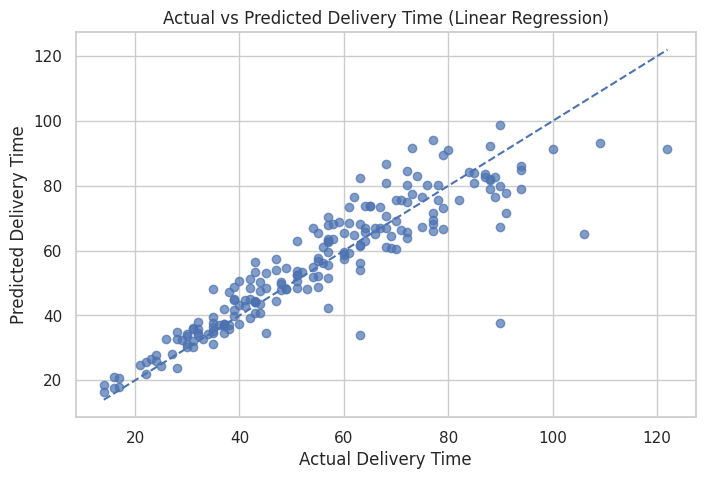

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred_best, alpha=0.7)
plt.xlabel("Actual Delivery Time")
plt.ylabel("Predicted Delivery Time")
plt.title(f"Actual vs Predicted Delivery Time ({best_model_name})")

min_val = min(y_test.min(), y_pred_best.min())
max_val = max(y_test.max(), y_pred_best.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.show()

### Observation

If the predictions are good, the points should lie close to the diagonal line.

## 6.5 Feature Importance / Model Interpretation

In [ ]:
if best_model_name == "Linear Regression":
    feature_names = best_pipeline.named_steps["preprocessor"].get_feature_names_out()
    coefficients = best_pipeline.named_steps["model"].coef_

    coef_df = pd.DataFrame({
        "Feature": feature_names,
        "Coefficient": coefficients
    }).sort_values(by="Coefficient", key=np.abs, ascending=False)

    display(coef_df.head(15))

else:
    feature_names = best_pipeline.named_steps["preprocessor"].get_feature_names_out()
    importances = best_pipeline.named_steps["model"].feature_importances_

    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    }).sort_values(by="Importance", ascending=False)

    display(importance_df.head(15))

    plt.figure(figsize=(10,6))
    sns.barplot(data=importance_df.head(10), x="Importance", y="Feature")
    plt.title(f"Top 10 Feature Importance - {best_model_name}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.show()

,Feature,Coefficient
0,num__Distance_km,16.571444
1,num__Preparation_Time_min,6.559020
10,cat__Traffic_Level_High,5.411517
11,cat__Traffic_Level_Low,-5.262388
8,cat__Weather_Snowy,5.026166
5,cat__Weather_Clear,-4.248743
9,cat__Weather_Windy,-2.640554
2,num__Courier_Experience_yrs,-1.975222
6,cat__Weather_Foggy,1.493773
4,num__Distance_x_Prep_Time,0.811973


#

# SECTION 7: Business Insights and Recommendations

## 7.1 Key Findings

Based on the analysis and modeling process, delivery time is influenced by a combination of:

- travel distance
- preparation time
- traffic condition
- weather condition
- courier experience
- time of day

These factors can be operationally monitored and used to improve delivery estimation systems.

## 7.2 Business Recommendations

1. **Use predictive ETA models in the app**  
   Show customers more realistic delivery estimates.

2. **Allocate couriers more strategically**  
   Assign experienced couriers to difficult routes or busy periods.

3. **Adjust ETA during peak hours**  
   Incorporate rush hour and traffic conditions into operational planning.

4. **Monitor preparation time together with distance**  
   Delivery delay is not only caused by courier travel but also by kitchen readiness.

5. **Use the model as a decision-support tool**  
   The model can help operations teams anticipate delays and improve service quality.

## 7.3 Conclusion

This project demonstrates an end-to-end **data science workflow**:

- business understanding
- data inspection
- exploratory data analysis
- feature engineering
- preprocessing
- regression modeling
- model evaluation
- business recommendation

The final output is a predictive model that can help food delivery companies estimate delivery time more accurately and improve operational performance.

## 7.4 Next Improvement

For future work, this project can be improved by:

- tuning model hyperparameters
- trying XGBoost or LightGBM
- incorporating geospatial information
- including restaurant workload and courier availability
- deploying the model into a dashboard or web app